# Napoli Attack Comparison

This notebook runs the Napoli team attack analysis from `code.py` and compares Napoli with the other Champions League teams in the available StatsBomb event data.

In [1]:
%matplotlib inline

import importlib.util
import pandas as pd
from pathlib import Path

module_path = Path("code.py").resolve()
spec = importlib.util.spec_from_file_location("napoli_attack", module_path)
napoli_attack = importlib.util.module_from_spec(spec)
spec.loader.exec_module(napoli_attack)

TARGET_TEAM = napoli_attack.TARGET_TEAM
TARGET_TEAM

'Napoli'

## Build Team Attack Dataset

In [2]:
team_stats = napoli_attack.collect_team_attack_stats()
team_stats = team_stats[team_stats["Matches"] >= napoli_attack.MIN_TEAM_MATCHES].copy()
team_stats = napoli_attack.add_team_rates(team_stats)

rank_table = napoli_attack.get_rank_table(team_stats)
napoli_row = napoli_attack.get_target_team_row(team_stats)

print(f"Teams included: {team_stats['Team'].nunique()}")
print(f"Available matches included: {len(napoli_attack.get_statsbomb_ids())}")

Teams included: 36
Available matches included: 144


## Napoli Attacking Profile

In [3]:
profile_cols = [
    "Team",
    "Matches",
    "Shots",
    "Goals",
    "xG",
    "xG per Match",
    "Open Play xG per Match",
    "Shots per Match",
    "xG per Shot",
    "Touches Box per Match",
    "Passes Into Box per Match",
    "Progressive Passes per Match",
    "OBV Total per Match",
]

napoli_profile = napoli_row[profile_cols].to_frame().T
napoli_profile.round(2)

,Team,Matches,Shots,Goals,xG,xG per Match,Open Play xG per Match,Shots per Match,xG per Shot,Touches Box per Match,Passes Into Box per Match,Progressive Passes per Match,OBV Total per Match
31,Napoli,8,95,8,9.174354,1.146794,1.048857,11.875,0.096572,78.875,16.625,122.125,0.850721


## Napoli Ranks Against Other Teams

In [4]:
display_cols = [
    "Team",
    "Matches",
    "xG per Match",
    "xG per Match Rank",
    "Shots per Match",
    "Shots per Match Rank",
    "Touches Box per Match",
    "Touches Box per Match Rank",
    "Passes Into Box per Match",
    "Passes Into Box per Match Rank",
    "OBV Total per Match",
    "OBV Total per Match Rank",
]

rank_table[display_cols].round(2)

,Team,Matches,xG per Match,xG per Match Rank,Shots per Match,Shots per Match Rank,Touches Box per Match,Touches Box per Match Rank,Passes Into Box per Match,Passes Into Box per Match Rank,OBV Total per Match,OBV Total per Match Rank
20,Liverpool,8,2.44,1,19.75,2,111.00,1,22.88,1,2.86,4
1,Arsenal,8,2.38,2,16.62,7,85.75,7,17.12,7,2.90,3
18,Bayern Munich,8,2.34,3,17.50,5,89.12,5,17.88,5,2.73,7
8,Real Madrid,8,2.23,4,19.50,3,84.88,9,15.88,10,3.16,1
22,Paris Saint-Germain,8,2.08,5,21.50,1,100.75,2,20.50,3,2.46,8
17,Inter Milan,8,2.01,6,16.88,6,90.38,4,20.75,2,2.24,10
23,Atalanta,8,1.83,7,14.88,11,77.88,15,14.38,14,1.71,24
15,Bodø / Glimt,8,1.82,8,12.38,22,66.88,22,14.38,14,3.08,2
33,Barcelona,8,1.78,9,17.75,4,82.25,11,15.88,10,1.91,20
32,Newcastle United,8,1.74,10,13.00,18,82.25,11,15.75,12,2.40,9


## Napoli Shooting Summary

In [5]:
napoli_shots = napoli_attack.collect_team_shots(TARGET_TEAM)
pd.DataFrame([
    napoli_attack.summarize_team_shooting(napoli_shots, TARGET_TEAM)
])

,Team,Shots,Goals,xG,xG / Shot,Shot Accuracy %,Conversion %,Shots in Box,Box Shot %
0,Napoli,95,8,9.17,0.097,29.5%,8.4%,68,71.6%


## Passing Analysis

This section checks whether Napoli mainly circulated possession or turned passing into progression and chance creation.

In [6]:
napoli_events = napoli_attack.collect_team_events_df(TARGET_TEAM)
napoli_passes = napoli_attack.collect_team_passes(TARGET_TEAM)

print(f"Napoli events: {len(napoli_events):,}")
print(f"Napoli passes: {len(napoli_passes):,}")


Napoli events: 15,031
Napoli passes: 4,460


### Passing Summary

In [7]:
napoli_attack.summarize_passing(napoli_passes)


,Passes,Completed,Completion %,Average Length,Median Length,Progressive Passes,Passes Into Final Third,Passes Into Box,Shot Assists,Goal Assists,Lofted Long Balls,Under Pressure Completion %,No Pressure Completion %
0,4460,3806,85.34,20.14,17.01,1310,409,300,69,6,374,75.29,87.43


### Pass Categories

In [8]:
napoli_attack.passing_category_table(napoli_passes)


,Category,Value,Passes,Completion %
0,Height,Ground Pass,3345,94.92
1,Height,High Pass,647,47.60
2,Height,Low Pass,468,69.02
11,Outcome,Complete,3806,100.00
12,Outcome,Incomplete,583,0.00
14,Outcome,Out,46,0.00
16,Outcome,Unknown,16,0.00
15,Outcome,Pass Offside,8,0.00
13,Outcome,Injury Clearance,1,0.00
9,Type,Regular,3830,86.95


### Ball Loss and Event Categories

In [9]:
napoli_attack.passing_loss_table(napoli_events, napoli_passes)


,Metric,Count
0,Ball losses,1050
3,Bad passes,654
1,Unintentional losses,396
10,Lofted long balls,374
5,Deliberate losses,330
4,Bad passes successful,206
8,Fouls committed,122
6,Shots,95
7,Clearances,95
2,Turnovers,75


### Pass Length and Outcome

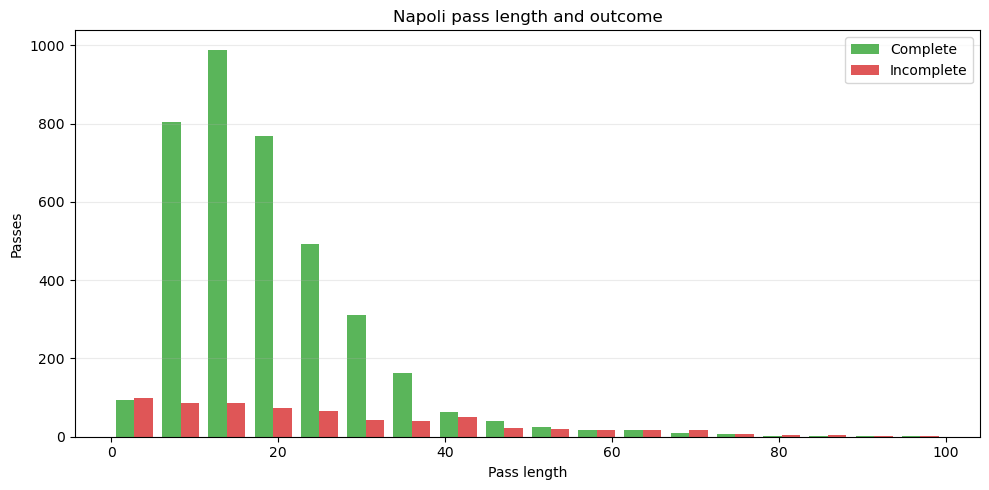

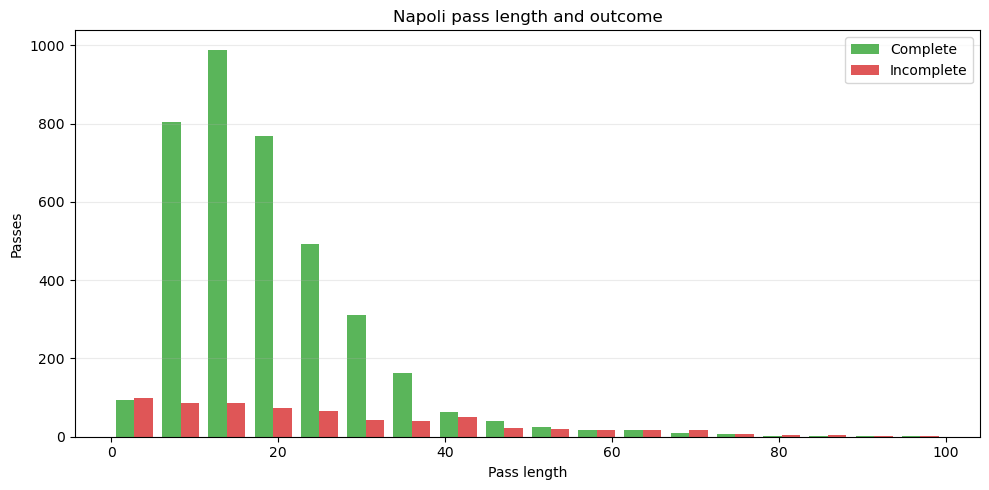

In [10]:
fig_pass_length, ax_pass_length = napoli_attack.plot_pass_length_outcome(napoli_passes, TARGET_TEAM)
fig_pass_length


### Volume vs Efficiency

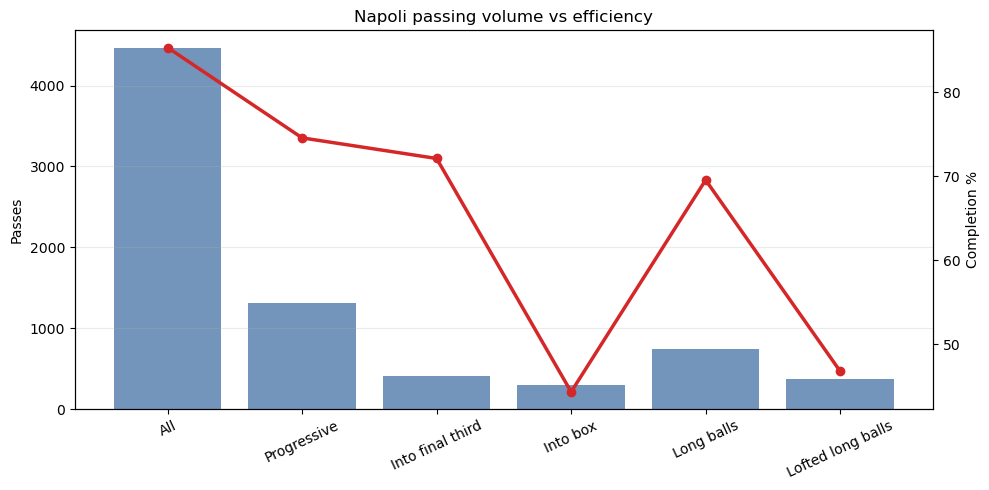

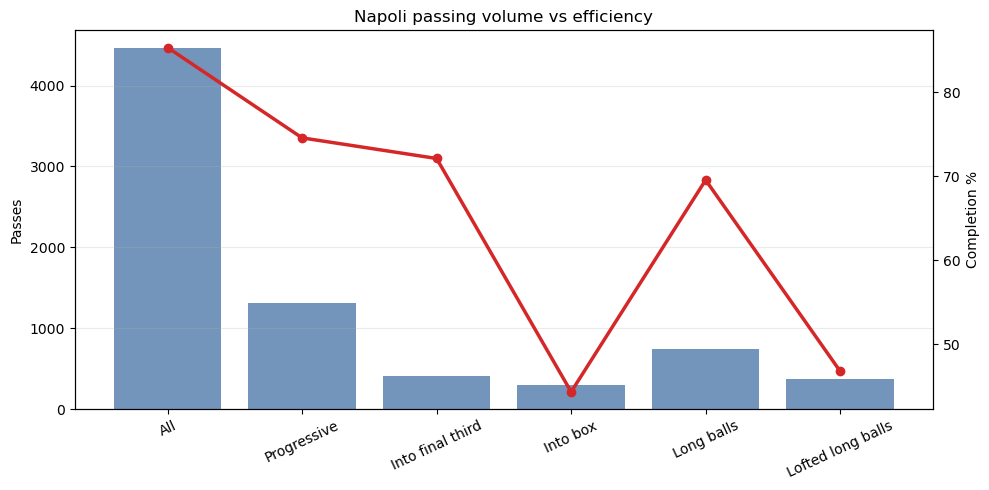

In [11]:
fig_vol_eff, ax_vol_eff = napoli_attack.plot_passing_volume_efficiency(napoli_passes, TARGET_TEAM)
fig_vol_eff


### Pressure Impact

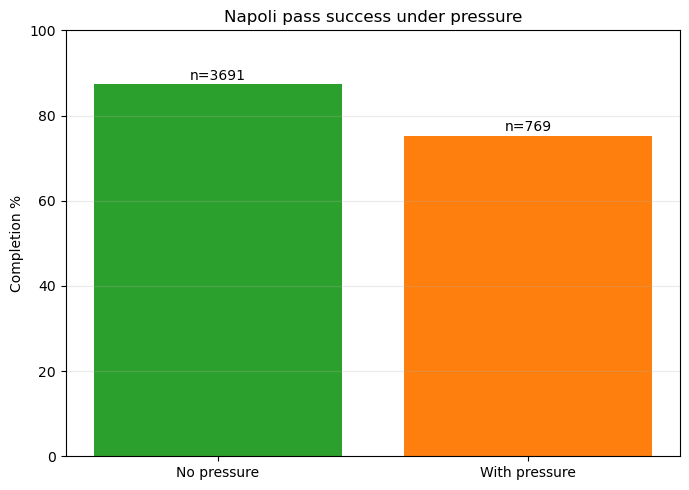

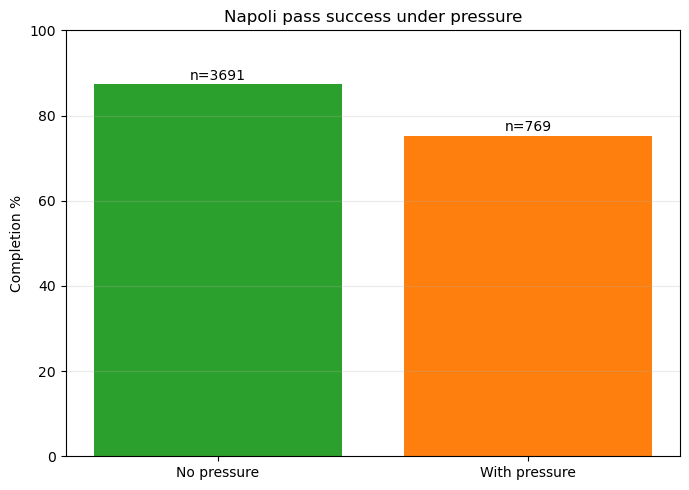

In [12]:
fig_pressure, ax_pressure = napoli_attack.plot_pressure_pass_success(napoli_passes, TARGET_TEAM)
fig_pressure


### Pass Heatmaps

The grids use larger squares so the spatial picture is easier to read and less noisy.

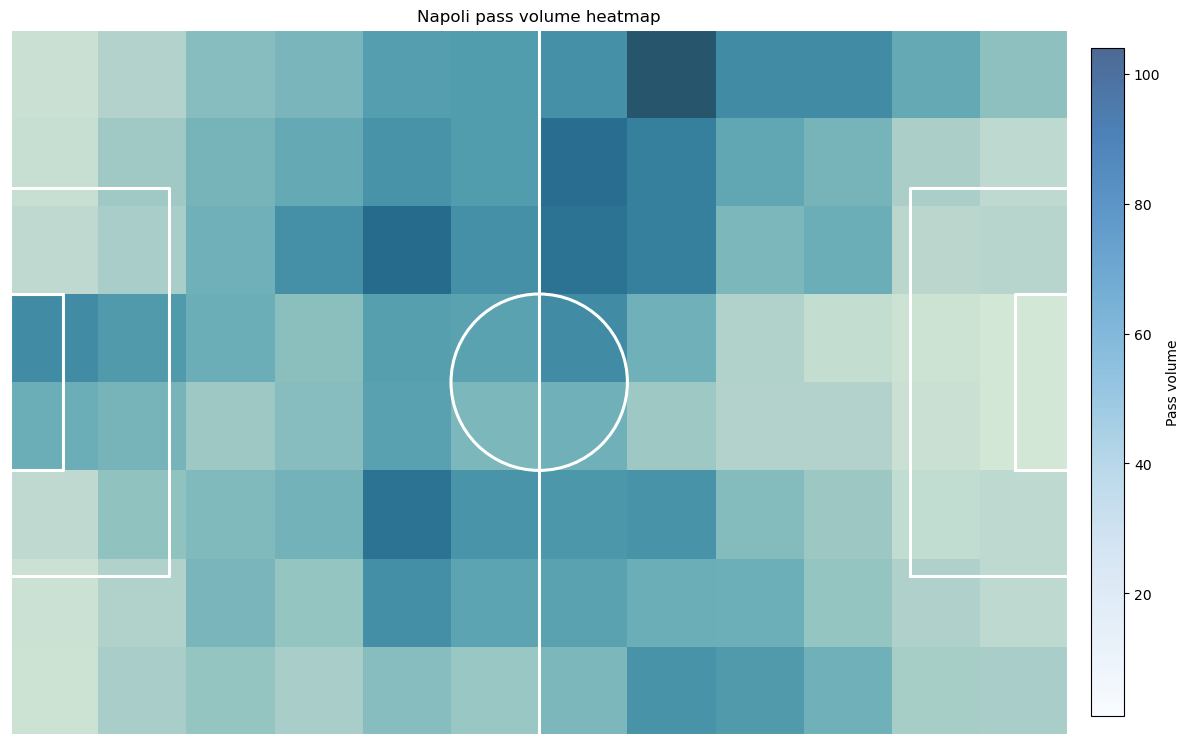

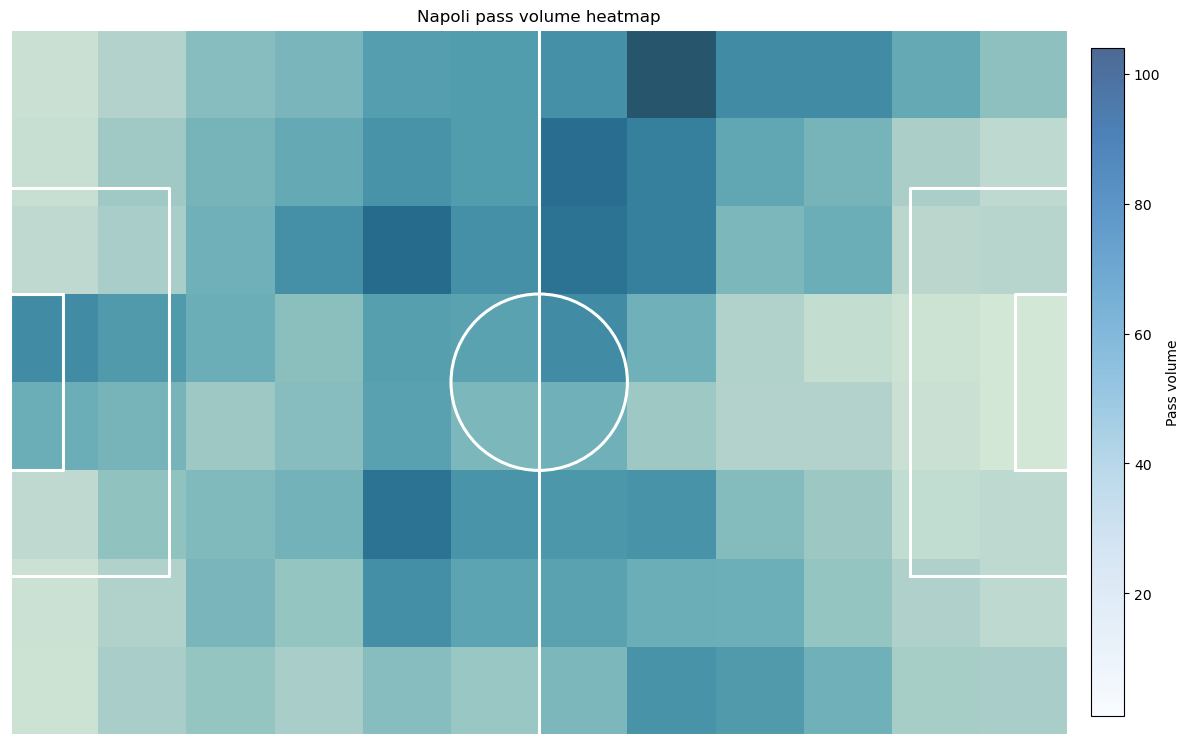

In [13]:
fig_pass_volume, ax_pass_volume = napoli_attack.plot_pass_start_heatmap(napoli_passes, TARGET_TEAM, bins=(12, 8))
fig_pass_volume


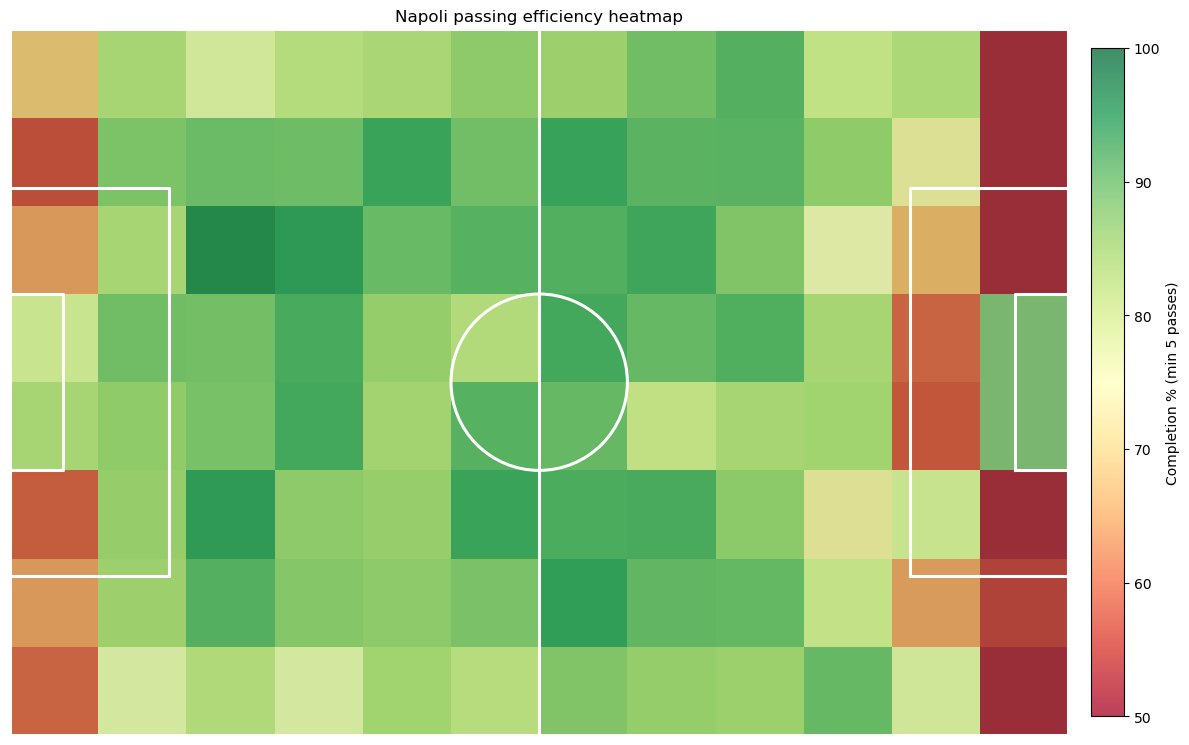

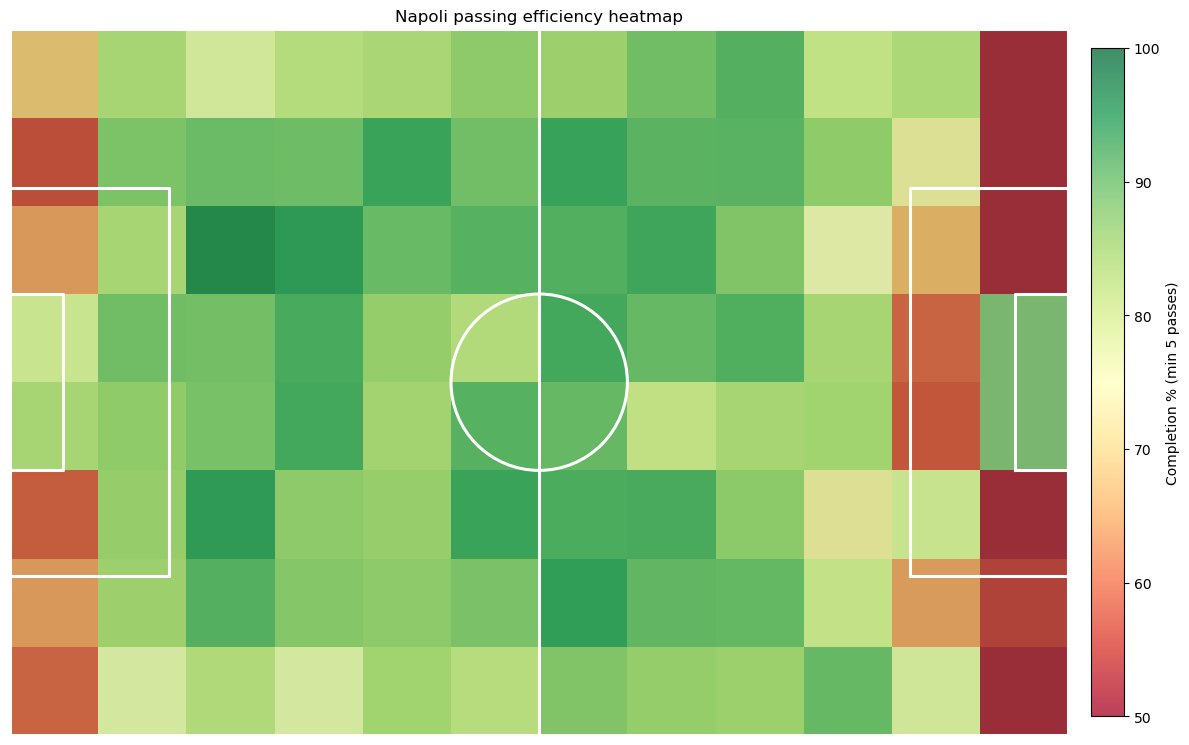

In [14]:
fig_pass_eff, ax_pass_eff = napoli_attack.plot_pass_efficiency_heatmap(napoli_passes, TARGET_TEAM, bins=(12, 8), min_passes=5)
fig_pass_eff


### Unintentional Losses Heatmap

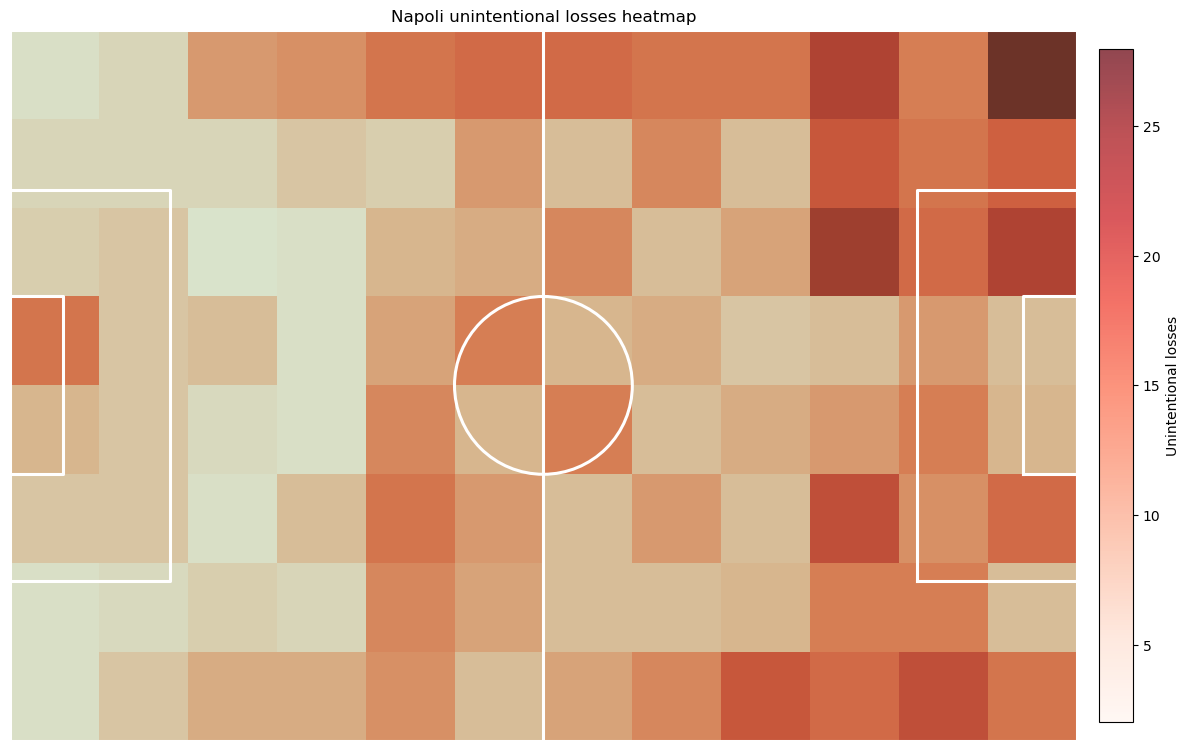

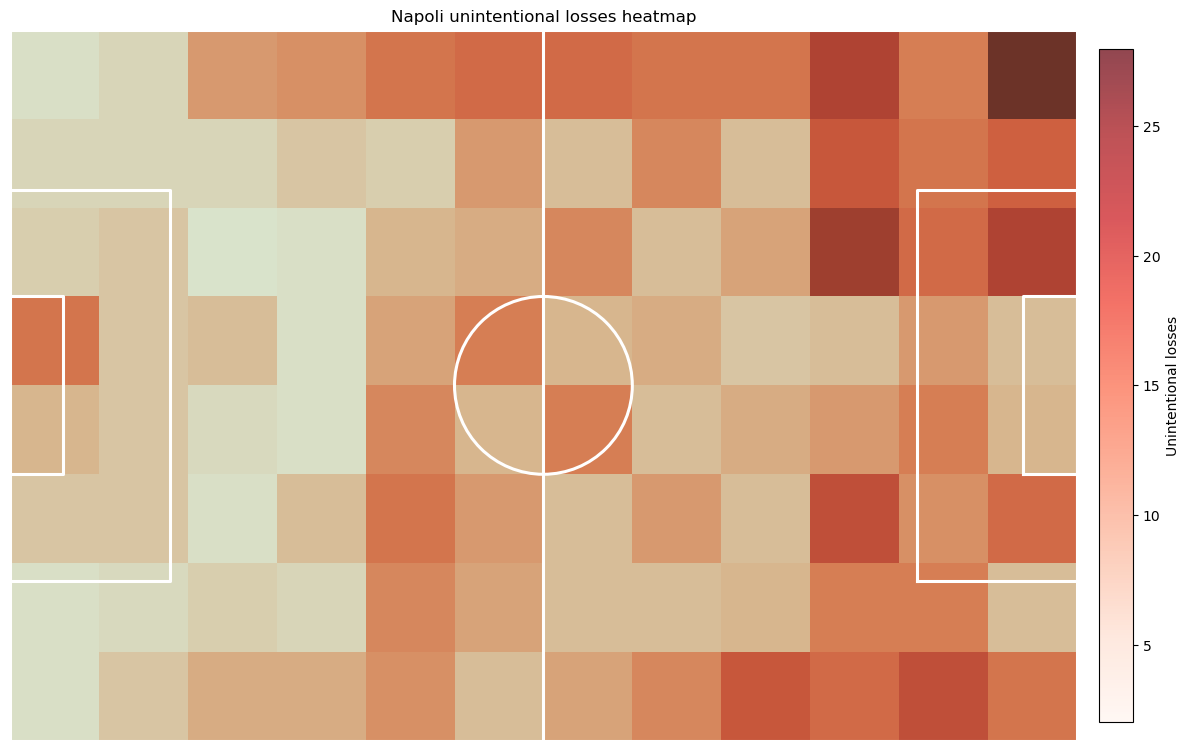

In [15]:
fig_unintentional, ax_unintentional = napoli_attack.plot_unintentional_losses_heatmap(
    napoli_events,
    napoli_passes,
    TARGET_TEAM,
    bins=(12, 8),
)
fig_unintentional


### Viewable Passing Outputs

These are pre-rendered from the same code above, so they are visible immediately when the notebook opens. Re-run the code cells if the data changes.


#### Passing Summary
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Passes</th>
      <th>Completed</th>
      <th>Completion %</th>
      <th>Average Length</th>
      <th>Median Length</th>
      <th>Progressive Passes</th>
      <th>Passes Into Final Third</th>
      <th>Passes Into Box</th>
      <th>Shot Assists</th>
      <th>Goal Assists</th>
      <th>Lofted Long Balls</th>
      <th>Under Pressure Completion %</th>
      <th>No Pressure Completion %</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>4460</td>
      <td>3806</td>
      <td>85.34</td>
      <td>20.14</td>
      <td>17.01</td>
      <td>1310</td>
      <td>409</td>
      <td>300</td>
      <td>69</td>
      <td>6</td>
      <td>374</td>
      <td>75.29</td>
      <td>87.43</td>
    </tr>
  </tbody>
</table>

#### Pass Categories
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Category</th>
      <th>Value</th>
      <th>Passes</th>
      <th>Completion %</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Height</td>
      <td>Ground Pass</td>
      <td>3345</td>
      <td>94.92</td>
    </tr>
    <tr>
      <td>Height</td>
      <td>High Pass</td>
      <td>647</td>
      <td>47.60</td>
    </tr>
    <tr>
      <td>Height</td>
      <td>Low Pass</td>
      <td>468</td>
      <td>69.02</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Complete</td>
      <td>3806</td>
      <td>100.00</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Incomplete</td>
      <td>583</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Out</td>
      <td>46</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Unknown</td>
      <td>16</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Pass Offside</td>
      <td>8</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>Outcome</td>
      <td>Injury Clearance</td>
      <td>1</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Regular</td>
      <td>3830</td>
      <td>86.95</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Recovery</td>
      <td>311</td>
      <td>69.13</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Throw-in</td>
      <td>108</td>
      <td>91.67</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Free Kick</td>
      <td>88</td>
      <td>92.05</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Corner</td>
      <td>49</td>
      <td>48.98</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Goal Kick</td>
      <td>39</td>
      <td>61.54</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Kick Off</td>
      <td>23</td>
      <td>100.00</td>
    </tr>
    <tr>
      <td>Type</td>
      <td>Interception</td>
      <td>12</td>
      <td>83.33</td>
    </tr>
  </tbody>
</table>

#### Ball Loss and Event Categories
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Metric</th>
      <th>Count</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Ball losses</td>
      <td>1050</td>
    </tr>
    <tr>
      <td>Bad passes</td>
      <td>654</td>
    </tr>
    <tr>
      <td>Unintentional losses</td>
      <td>396</td>
    </tr>
    <tr>
      <td>Lofted long balls</td>
      <td>374</td>
    </tr>
    <tr>
      <td>Deliberate losses</td>
      <td>330</td>
    </tr>
    <tr>
      <td>Bad passes successful</td>
      <td>206</td>
    </tr>
    <tr>
      <td>Fouls committed</td>
      <td>122</td>
    </tr>
    <tr>
      <td>Shots</td>
      <td>95</td>
    </tr>
    <tr>
      <td>Clearances</td>
      <td>95</td>
    </tr>
    <tr>
      <td>Turnovers</td>
      <td>75</td>
    </tr>
    <tr>
      <td>Offside passes</td>
      <td>8</td>
    </tr>
  </tbody>
</table>

#### Passing Figures

![Pass length and outcome](figures/final_report/napoli_pass_length_outcome.png)

![Pass categories](figures/final_report/napoli_pass_categories.png)

![Passing volume vs efficiency](figures/final_report/napoli_passing_volume_efficiency.png)

![Pressure pass success](figures/final_report/napoli_pressure_pass_success.png)

![Pass volume heatmap](figures/final_report/napoli_pass_volume_heatmap.png)

![Pass efficiency heatmap](figures/final_report/napoli_pass_efficiency_heatmap.png)

![Unintentional losses heatmap](figures/final_report/napoli_unintentional_losses_heatmap.png)


## Visual Comparisons

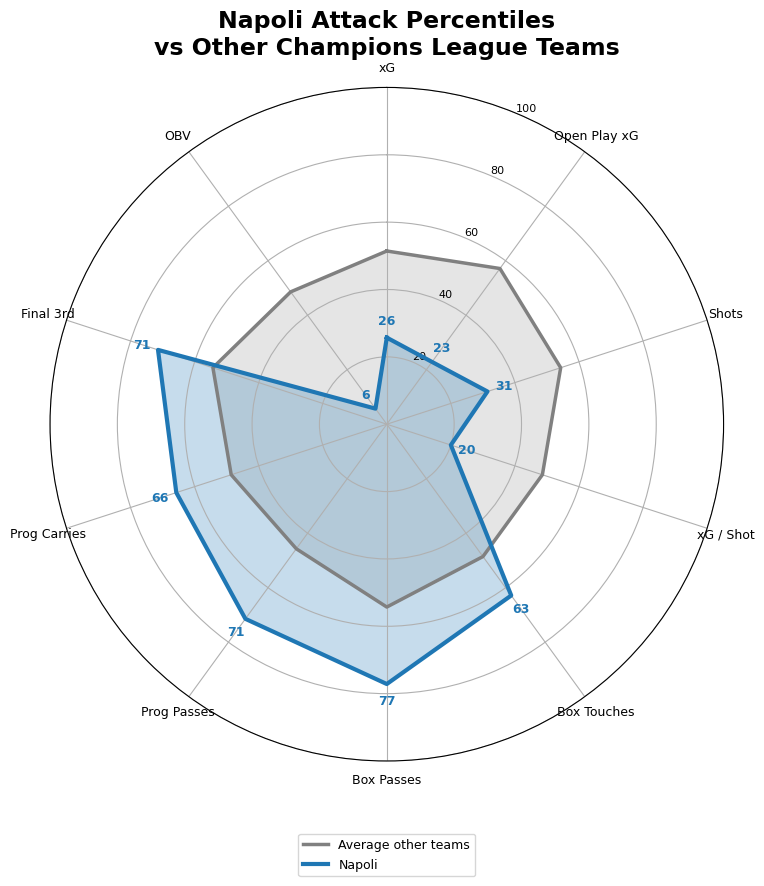

In [16]:
napoli_attack.plot_team_attack_radar(team_stats)

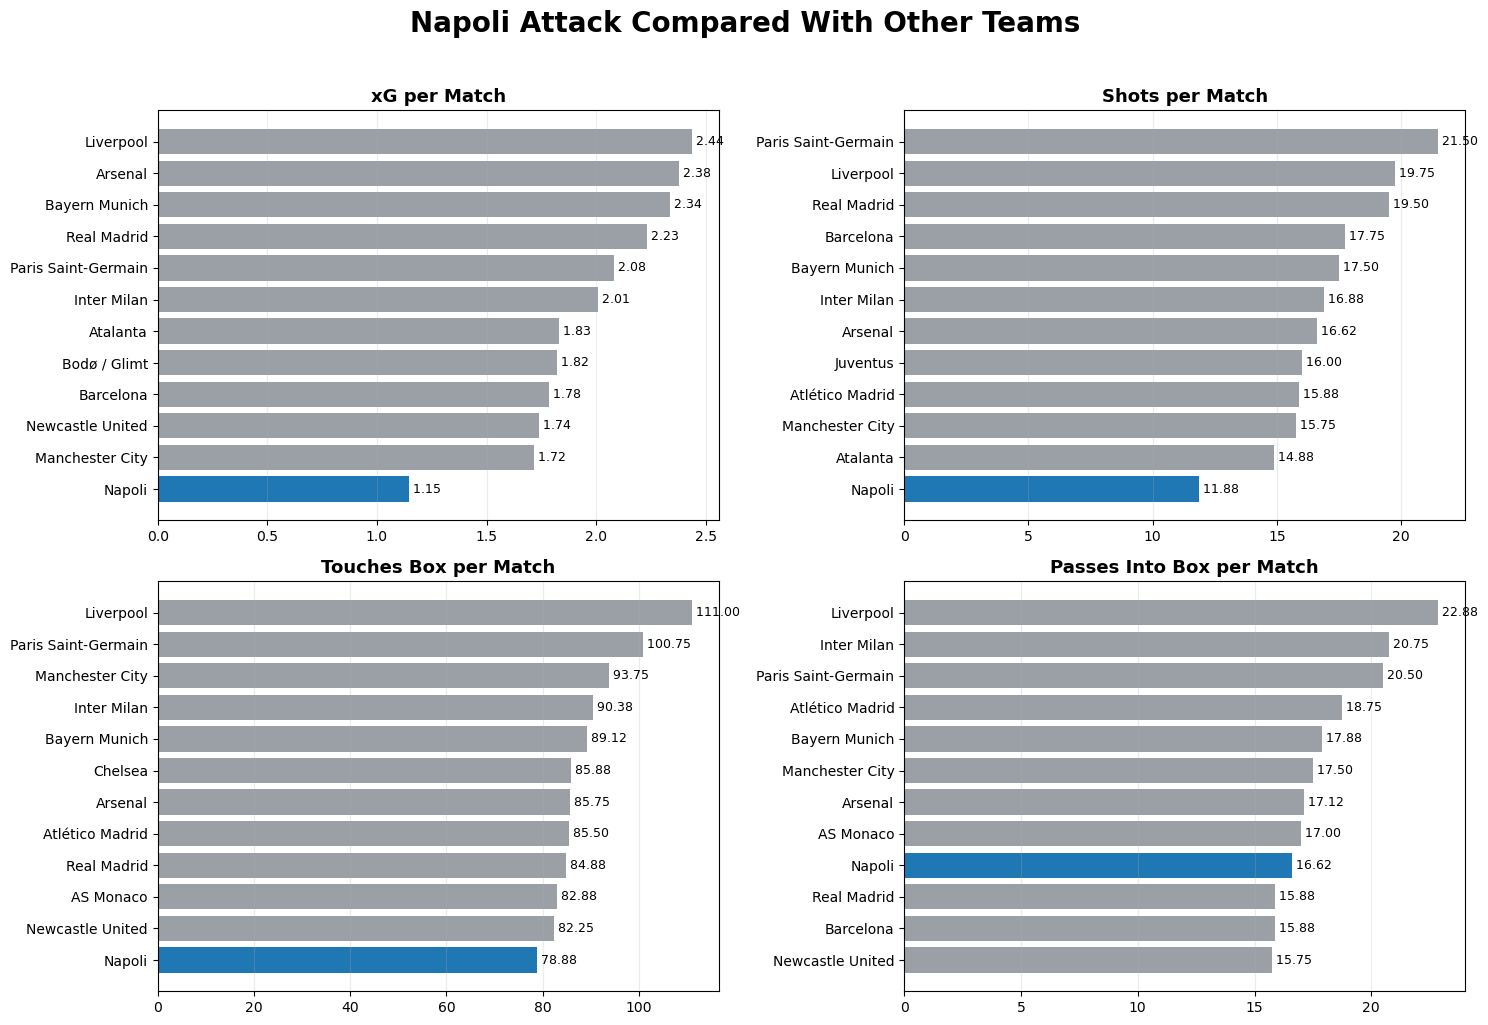

In [17]:
napoli_attack.plot_attack_ranking_bars(team_stats)

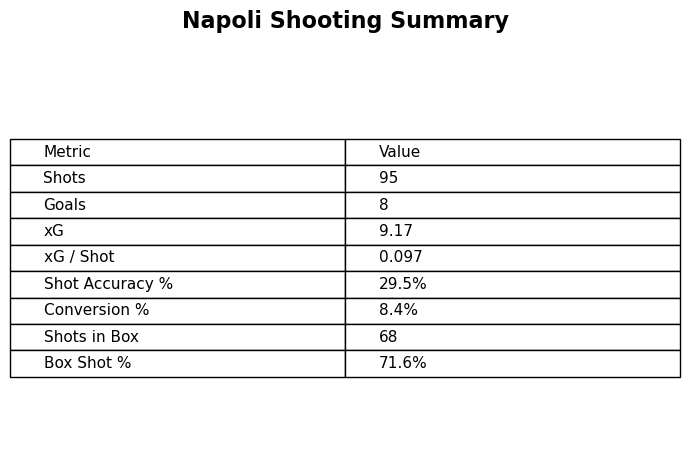

In [18]:
napoli_attack.plot_team_shooting_summary_table(napoli_shots, TARGET_TEAM)

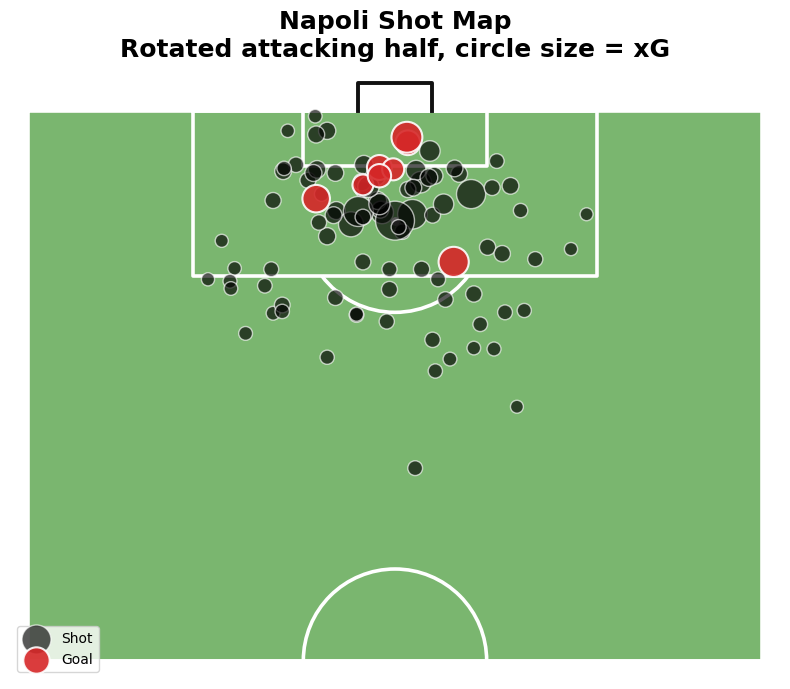

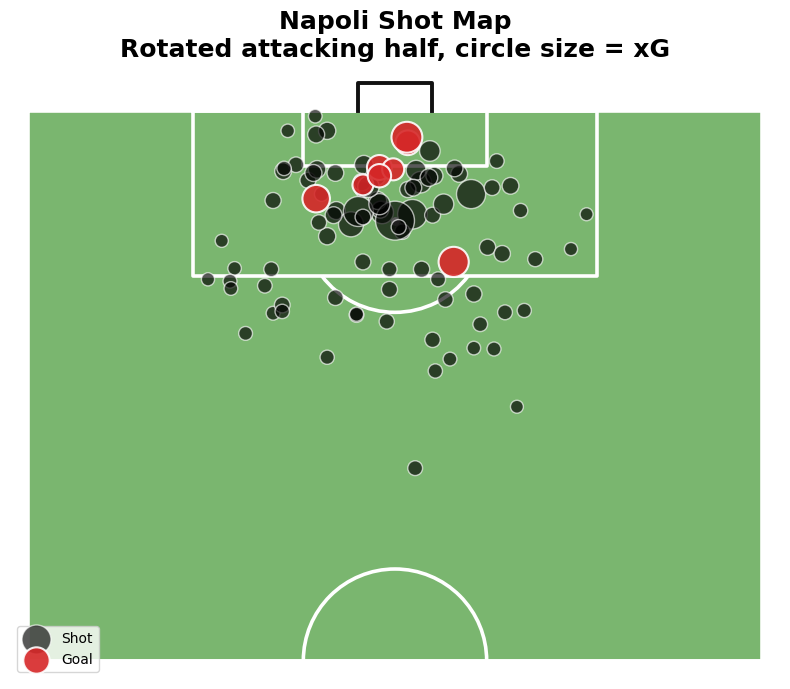

In [19]:
module_path = Path("code.py").resolve()
spec = importlib.util.spec_from_file_location("napoli_attack", module_path)
napoli_attack = importlib.util.module_from_spec(spec)
spec.loader.exec_module(napoli_attack)

TARGET_TEAM = napoli_attack.TARGET_TEAM
napoli_shots = napoli_attack.collect_team_shots(TARGET_TEAM)
fig_shot_map, ax_shot_map = napoli_attack.plot_team_shot_map(napoli_shots, TARGET_TEAM)
fig_shot_map
